# 11. SMS Spam Mesaj Sınıflandırması

**Kategori:** Doğal Dil İşleme (NLP)  
**Gerçek veri seti:** UCI SMS Spam Collection  
**Veri kaynağı:** [https://archive.ics.uci.edu/dataset/228/sms+spam+collection](https://archive.ics.uci.edu/dataset/228/sms+spam+collection)  
**Amaç:** Gerçek SMS metinlerini spam/normal olarak sınıflandırmak.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Metin EDA'sı

In [2]:
df = pd.read_csv(DATA_DIR / "sms_spam.csv")
df["length"] = df.message.str.len()
df["word_count"] = df.message.str.split().str.len()
display(df.head())
print("Boyut:", df.shape, "| Eksik:", int(df.isna().sum().sum()), "| Tekrar:", df.duplicated().sum())
display(df.groupby("label")[["length", "word_count"]].agg(["count", "mean", "median"]).round(1))

Boyut: (5572, 4) | Eksik: 0 | Tekrar: 403


,label,message,length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


length               word_count             
       count   mean median      count  mean median
label                                             
ham     4825   71.5   52.0       4825  14.3   11.0
spam     747  138.7  149.0        747  23.9   25.0

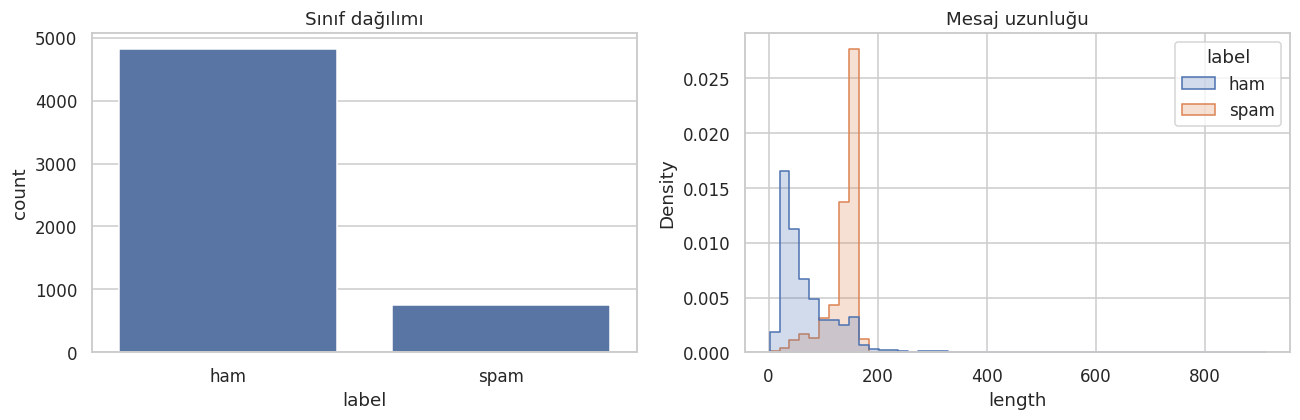

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="label", ax=axes[0])
axes[0].set(title="Sınıf dağılımı")
sns.histplot(data=df, x="length", hue="label", bins=50, element="step", stat="density",
             common_norm=False, ax=axes[1])
axes[1].set(title="Mesaj uzunluğu")
plt.tight_layout(); plt.show()

## 2. TF-IDF ve model karşılaştırması

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.95      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



,precision_spam,recall_spam,f1_spam
Lojistik Regresyon,0.945,0.926,0.936
Naive Bayes,1.000,0.705,0.827


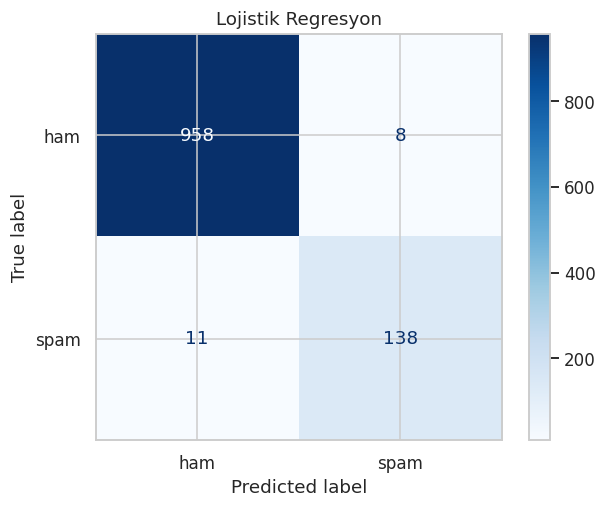

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

X_train, X_test, y_train, y_test = train_test_split(
    df.message, df.label, test_size=.20, stratify=df.label, random_state=RANDOM_STATE
)
candidates = {
    "Naive Bayes": make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2), MultinomialNB()),
    "Lojistik Regresyon": make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2),
                                        LogisticRegression(max_iter=2000, class_weight="balanced")),
}
fitted = {name: model.fit(X_train, y_train) for name, model in candidates.items()}
rows = {name: {"precision_spam": precision_score(y_test, model.predict(X_test), pos_label="spam"),
               "recall_spam": recall_score(y_test, model.predict(X_test), pos_label="spam"),
               "f1_spam": f1_score(y_test, model.predict(X_test), pos_label="spam")}
        for name, model in fitted.items()}
scores = pd.DataFrame(rows).T.sort_values("f1_spam", ascending=False)
display(scores.round(3))
best_name = scores.index[0]; best_model = fitted[best_name]; pred = best_model.predict(X_test)
print(classification_report(y_test, pred))
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap="Blues")
plt.title(best_name); plt.show()

In [5]:
joblib.dump({"best_name": best_name, "best_model": best_model,
             "all_models": fitted, "metrics": scores.to_dict()}, MODEL_DIR / "11_sms_spam.joblib")
json.dump({"best_model": best_name, **scores.loc[best_name].to_dict()},
          open(RESULT_DIR / "11_sms_spam.json", "w"), indent=2)
print(best_model.predict(["Congratulations! You won a free prize, call now.",
                          "Can we meet at the office at 3 pm?"]))

['spam' 'ham']


## Sonuç

Veri dengesiz olduğu için spam sınıfının F1 değeri model seçiminde kullanıldı. Rastgele yazılmış ve
çoğaltılmış birkaç cümle yerine 5.574 gerçek SMS üzerinde çalışıldı. TF-IDF yalnızca eğitim
bölümünde öğrenildiği için sözlük sızıntısı oluşmadı.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **TF-IDF ile metin sınıflandırma** biçimindedir.
Bu notebookta **5.574 gerçek SMS, uzunluk EDA'sı, iki metin Pipeline'ı ve spam sınıfına özel metrikler** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).